# Assignment 2 — Task 3: Cognitive Load and the Data-Ink Ratio
**Student:** Talha Abdullah Bangyal  
**Course:** Data Visualization  
**Roll Number:** SU92-BAIFM-F25-002  
**Datasets:** `car_crashes.csv` (51 rows), `tips.csv` (244 rows)  

---
## 1. Overview and Theoretical Framework

### Cognitive Load Theory (John Sweller, 1988)
Human working memory is severely bottlenecked, reliably holding only **4 ± 1 chunks** of novel information at any instant (Cowan, 2001). Cognitive load across visual tasks is partitioned into three distinct types:
1. **Intrinsic Load:** The inherent difficulty of the data and domain problem itself (e.g., comparing 51 state distributions across collision factors). It cannot be removed, but it can be managed through chunking and visual hierarchy.
2. **Extraneous Load:** Mental effort wasted on decoding suboptimal design decisions (chart junk, 51-entry legends, heavy gridlines, arbitrary rainbow palettes, rotated text). **This must be systematically eliminated.**
3. **Germane Load:** Mental effort devoted to actual schema acquisition, pattern discovery, and meaningful interpretation. **This must be protected and fostered.**

### The Data-Ink Ratio (Edward Tufte, 1983)
$$\text{Data-Ink Ratio} = \frac{\text{Data-Ink (ink used to display data)}}{\text{Total Ink in the Graphic}}$$

Tufte advises maximizing the data-ink ratio by stripping away non-data marks, but this heuristic breaks down if taken to an extreme where essential reference anchors (axes, units, baselines) are destroyed.

In this notebook, we:
1. Construct an intentionally overloaded chart (`BAD EXAMPLE`) on `car_crashes.csv`.
2. Formally classify all visual elements by cognitive load type and calculate the empirical data-ink ratio.
3. Systematically declutter the visualization across a **5-panel progressive deconstruction**.
4. Apply the **4 ± 1 chunking limit** to redesign the data into four manageable chunks.
5. Create an over-stripped chart (`BAD EXAMPLE`) to prove why data-ink ratio cannot be blindly maximized, providing a definitive stopping rule.
6. Use `tips.csv` to prove how **adding ink can actually lower cognitive load**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Matplotlib styling for publication-quality perception figures
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

# Load car crashes and tips datasets
df_crashes = pd.read_csv('data/car_crashes.csv')
df_tips = pd.read_csv('data/tips.csv')
print(f"Loaded car_crashes: {df_crashes.shape} | tips: {df_tips.shape}")
df_crashes.head()


Loaded car_crashes: (51, 8) | tips: (244, 7)


,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


## Step 1: Build an Overloaded Chart on Purpose (`BAD EXAMPLE`)

We construct an intentionally catastrophic chart showing all 51 states (50 states + DC) on `total` crashes:
- 51 distinct rainbow hues (arbitrary nominal colour mapping on quantitative data).
- Heavy gridlines in both X and Y directions.
- Thick, heavy 4-sided bounding frame.
- 51-entry vertical legend taking up massive canvas space.
- 51 rotated x-axis tick labels.
- Title naming the axes rather than stating a finding.


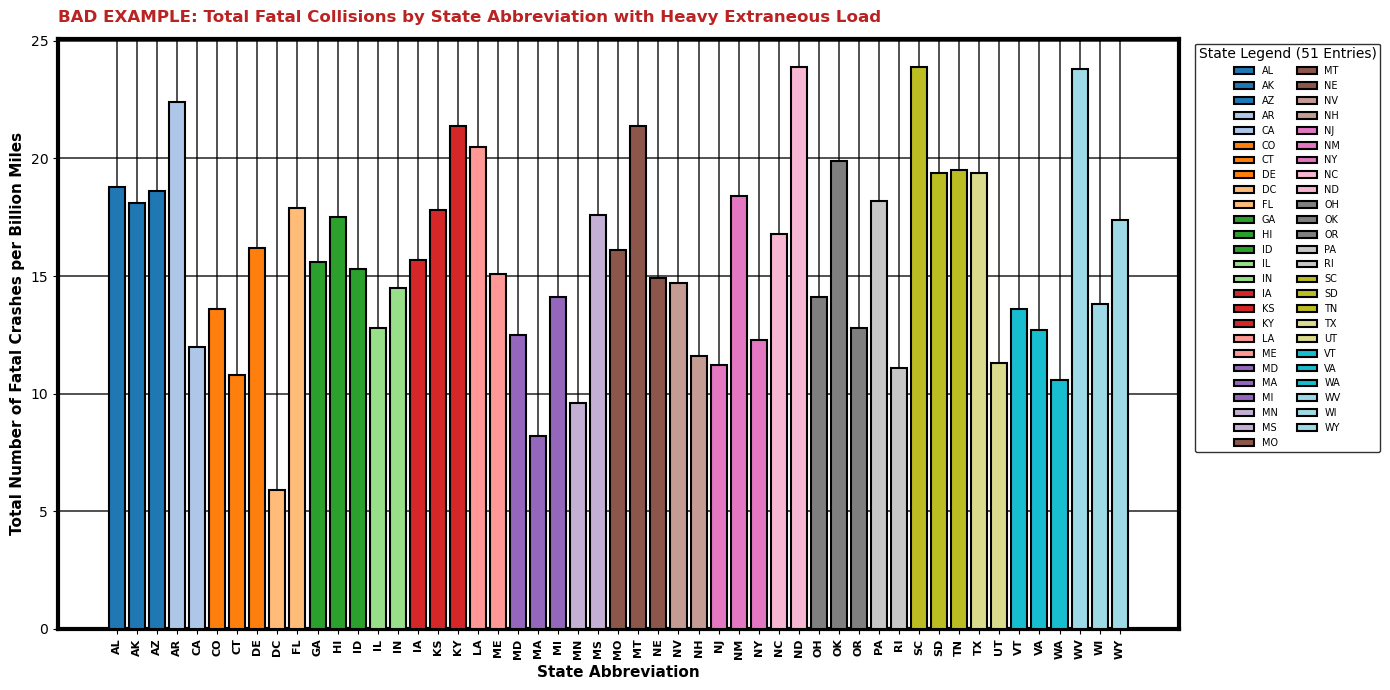

In [2]:
fig, ax = plt.subplots(figsize=(14, 7))

# 51 distinct rainbow colors
colors = plt.cm.tab20(np.linspace(0, 1, len(df_crashes)))

x = np.arange(len(df_crashes))
bars = ax.bar(x, df_crashes['total'], color=colors, edgecolor='black', linewidth=1.5, zorder=3)

# Heavy extraneous load elements
ax.set_xticks(x)
ax.set_xticklabels(df_crashes['abbrev'], rotation=90, fontsize=8, fontweight='bold')
ax.set_ylabel("Total Number of Fatal Crashes per Billion Miles", fontsize=11, fontweight='bold')
ax.set_xlabel("State Abbreviation", fontsize=11, fontweight='bold')

# Heavy gridlines in BOTH directions
ax.grid(True, which='both', color='black', linestyle='-', linewidth=1.2, alpha=0.8, zorder=0)

# Heavy box frame
for spine in ax.spines.values():
    spine.set_linewidth(3.0)
    spine.set_color('black')

# 51-entry legend
ax.legend(bars, df_crashes['abbrev'], bbox_to_anchor=(1.01, 1), loc='upper left', ncol=2, 
          fontsize=7, title="State Legend (51 Entries)", frameon=True, edgecolor='black')

ax.set_title("BAD EXAMPLE: Total Fatal Collisions by State Abbreviation with Heavy Extraneous Load", 
             loc='left', fontsize=12, fontweight='bold', color='#bb2222', pad=12)

fig.tight_layout()
plt.show()


### Perceptual Analysis of the Bad Example

- **Cognitive Overload:** The human eye is bombarded with 51 distinct hues, creating continuous visual vibration. Hue has no inherent perceptual ordering, so the reader searches for meaning where none exists.
- **Split-Attention Penalty:** The 51-item legend forces the eye into exhaustive saccades back and forth between the swatches and bars.
- **Visual Clutter:** Heavy black gridlines in front of and behind bars compete for contrast with the data edges. The thick border traps the eye within a dark visual cage.


## Step 2: Cognitive Load Classification and Data-Ink Calculation

### Cognitive Load Inventory Table

| Chart Element | Load Type | Justification | Action Required |
|---|---|---|---|
| Bar heights (51 values) | **Intrinsic** | Directly represents the crash rates (the data core). | Retain and emphasize |
| State abbreviations (x-axis) | **Germane** | Necessary to identify which state corresponds to which rate. | Retain, orient horizontally or sort |
| 51 rainbow colours | **Extraneous** | Distracts from quantity; implies false categorical grouping. | **Remove** (unify to grey/neutral) |
| 51-entry legend | **Extraneous** | Redundant with x-axis tick labels; induces split-attention. | **Remove completely** |
| Heavy vertical gridlines | **Extraneous** | Provides zero quantitative reference; slices across bars. | **Remove** |
| Heavy horizontal gridlines | **Extraneous** | Too prominent; overpowers bar tops. | **Lighten/soften to subtle dotted guide** |
| 4-sided black box spines | **Extraneous** | Decorative container ink carrying no information. | **Remove top and right spines** |
| Unsorted bar ordering | **Extraneous** | Forces observer to search randomly to find highest/lowest. | **Sort descending (enhances germane load)** |

---
### Empirical Data-Ink Ratio Estimation

$$\text{Data-Ink Ratio} = \frac{\text{Marks Encoding Data}}{\text{Total Visible Graphic Marks}}$$

**Working:**
1. **Data Marks ($N_{\text{data}}$):**
   - 51 bar heights encoding `total` fatal crash rates = **51 marks**.
2. **Total Graphic Marks ($N_{\text{total}}$):**
   - 51 bar fills = 51
   - 51 black bar outline strokes = 51
   - 51 distinct hue choices = 51
   - 51 x-axis tick labels = 51
   - 51 x-axis tick marks = 51
   - 51 legend color swatches = 51
   - 51 legend text labels = 51
   - 1 legend bounding box = 1
   - 15 heavy vertical gridlines = 15
   - 8 heavy horizontal gridlines = 8
   - 4 thick outer box spines = 4
   - Y-axis title + X-axis title + Main title = 3
   - **Total marks ($N_{\text{total}}$) $\approx 389$ marks**.

$$\text{Data-Ink Ratio} = \frac{51}{389} \approx \mathbf{0.131\; (13.1\%)}$$

Only **13% of the ink** in the graphic serves to encode quantitative information. The remaining 87% is chart junk producing extraneous mental friction.


## Step 3: Strip It Down, One Step at a Time (Five-Panel Progressive Deconstruction)

We deconstruct the chart across a **five-panel sequence** to demonstrate how each successive decluttering edit reduces extraneous load and elevates germane comprehension:
- **Panel 1:** Remove the 51-entry legend (eliminates split-attention).
- **Panel 2:** Remove box spines and vertical gridlines, lighten horizontal gridlines (cleans background).
- **Panel 3:** Drop 51 rainbow colours to a single muted neutral hue (stops visual vibration).
- **Panel 4:** Sort bars descending by crash rate (introduces perceptual ranking without adding ink).
- **Panel 5:** Label only what matters: grey context for all states, single pop-out in coral for South Carolina (highest crash rate), US average benchmark reference line, and direct data labels.


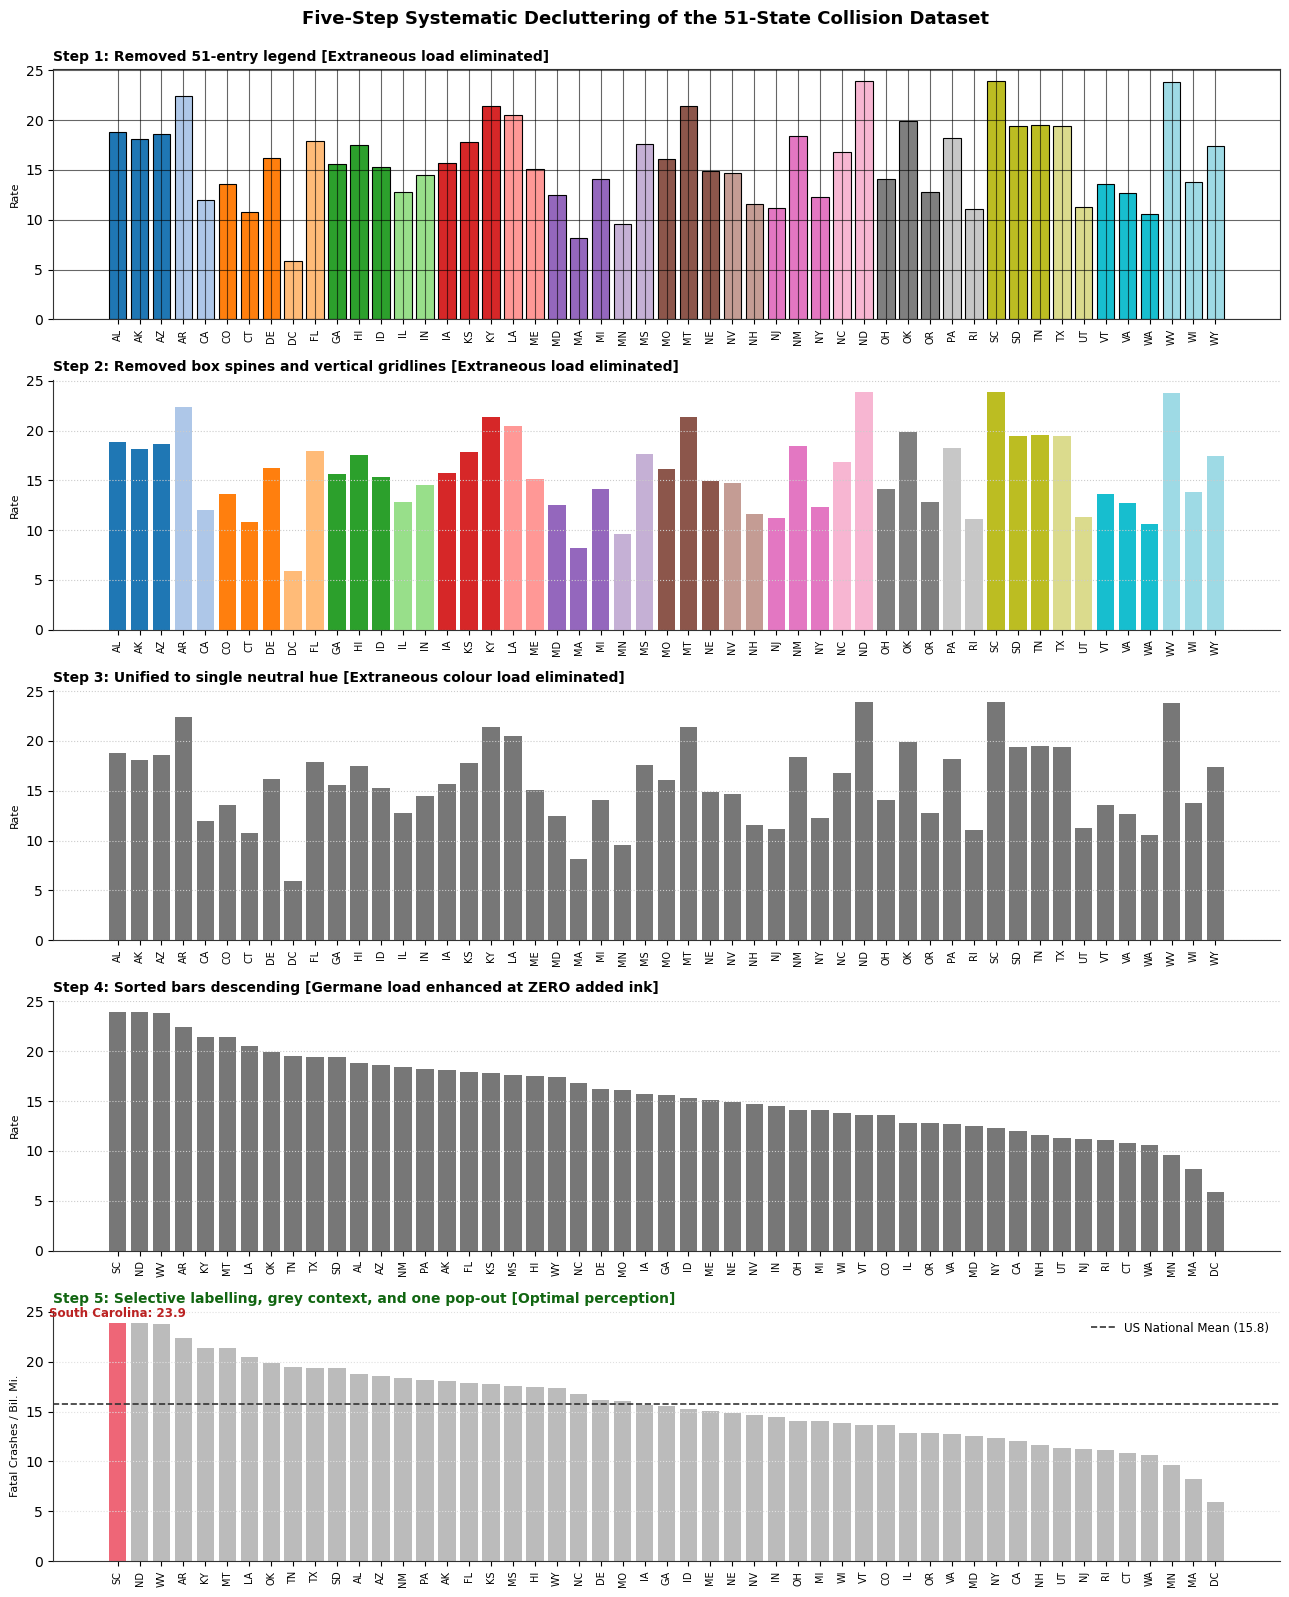

In [3]:
fig, axes = plt.subplots(5, 1, figsize=(13, 16), sharex=False)

x_raw = np.arange(len(df_crashes))
df_sorted = df_crashes.sort_values('total', ascending=False).reset_index(drop=True)
x_sorted = np.arange(len(df_sorted))
us_mean = df_crashes['total'].mean()

# Panel 1: Remove legend
axes[0].bar(x_raw, df_crashes['total'], color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_xticks(x_raw)
axes[0].set_xticklabels(df_crashes['abbrev'], rotation=90, fontsize=7)
axes[0].grid(True, which='both', color='black', alpha=0.6)
axes[0].set_title("Step 1: Removed 51-entry legend [Extraneous load eliminated]", loc='left', fontsize=10, fontweight='bold')
axes[0].set_ylabel("Rate", fontsize=8)

# Panel 2: Remove frame & vertical gridlines
axes[1].bar(x_raw, df_crashes['total'], color=colors, edgecolor='none')
axes[1].set_xticks(x_raw)
axes[1].set_xticklabels(df_crashes['abbrev'], rotation=90, fontsize=7)
for s in ['top', 'right']: axes[1].spines[s].set_visible(False)
axes[1].grid(axis='y', linestyle=':', color='#cccccc')
axes[1].set_title("Step 2: Removed box spines and vertical gridlines [Extraneous load eliminated]", loc='left', fontsize=10, fontweight='bold')
axes[1].set_ylabel("Rate", fontsize=8)

# Panel 3: Drop to single hue
axes[2].bar(x_raw, df_crashes['total'], color='#777777', edgecolor='none')
axes[2].set_xticks(x_raw)
axes[2].set_xticklabels(df_crashes['abbrev'], rotation=90, fontsize=7)
for s in ['top', 'right']: axes[2].spines[s].set_visible(False)
axes[2].grid(axis='y', linestyle=':', color='#cccccc')
axes[2].set_title("Step 3: Unified to single neutral hue [Extraneous colour load eliminated]", loc='left', fontsize=10, fontweight='bold')
axes[2].set_ylabel("Rate", fontsize=8)

# Panel 4: Sort bars descending
axes[3].bar(x_sorted, df_sorted['total'], color='#777777', edgecolor='none')
axes[3].set_xticks(x_sorted)
axes[3].set_xticklabels(df_sorted['abbrev'], rotation=90, fontsize=7)
for s in ['top', 'right']: axes[3].spines[s].set_visible(False)
axes[3].grid(axis='y', linestyle=':', color='#cccccc')
axes[3].set_title("Step 4: Sorted bars descending [Germane load enhanced at ZERO added ink]", loc='left', fontsize=10, fontweight='bold')
axes[3].set_ylabel("Rate", fontsize=8)

# Panel 5: Label only what matters (Context in grey, One pop-out in colour)
bar_colors = ['#ee6677' if i == 0 else '#bbbbbb' for i in range(len(df_sorted))]
axes[4].bar(x_sorted, df_sorted['total'], color=bar_colors, edgecolor='none')
axes[4].axhline(us_mean, color='#333333', linestyle='--', linewidth=1.2, label=f"US National Mean ({us_mean:.1f})")
axes[4].set_xticks(x_sorted)
axes[4].set_xticklabels(df_sorted['abbrev'], rotation=90, fontsize=7)
for s in ['top', 'right']: axes[4].spines[s].set_visible(False)
axes[4].grid(axis='y', linestyle=':', color='#e0e0e0')

# Direct label for pop-out
top_state = df_sorted.iloc[0]
axes[4].text(0, top_state['total'] + 0.6, f"South Carolina: {top_state['total']:.1f}", 
             ha='center', fontsize=8.5, fontweight='bold', color='#bb2222')
axes[4].set_title("Step 5: Selective labelling, grey context, and one pop-out [Optimal perception]", 
                  loc='left', fontsize=10, fontweight='bold', color='#116611')
axes[4].set_ylabel("Fatal Crashes / Bil. Mi.", fontsize=8)
axes[4].legend(frameon=False, loc='upper right', fontsize=8.5)

fig.suptitle("Five-Step Systematic Decluttering of the 51-State Collision Dataset", 
             fontsize=13, fontweight='bold', y=0.995)
fig.tight_layout()
plt.show()


### Critical Observation: Sorting Adds Zero Ink but Delivers Massive Value

Notice the transition from **Step 3 to Step 4**:
- The ink used is **identical to the micro-gram**. Not a single line, pixel, or label was added.
- Yet, the cognitive value jumped dramatically. In Step 3, finding the highest state or median state requires an $O(N)$ sequential visual scan of 51 bars. In Step 4, the ranking is encoded directly into **1D horizontal position** (the highest-ranking visual channel).
- **Takeaway:** Perceptual layout and grouping have far higher leverage than raw ink reduction alone.


## Step 4: Respect the 4 ± 1 Working Memory Limit

To comply with Cowan's **4 ± 1 chunking limit**, a reader must not be forced to hold 51 distinct items in working memory. We aggregate the 50 states + DC into **four US Census Regions** (Northeast, Midwest, West, South) plus the National Mean benchmark:
- **South:** Alabama, Arkansas, Delaware, DC, Florida, Georgia, Kentucky, Louisiana, Maryland, Mississippi, North Carolina, Oklahoma, South Carolina, Tennessee, Texas, Virginia, West Virginia.
- **Midwest:** Illinois, Indiana, Iowa, Kansas, Michigan, Minnesota, Missouri, Nebraska, North Dakota, Ohio, South Dakota, Wisconsin.
- **West:** Alaska, Arizona, California, Colorado, Hawaii, Idaho, Montana, Nevada, New Mexico, Oregon, Utah, Washington, Wyoming.
- **Northeast:** Connecticut, Maine, Massachusetts, New Hampshire, New Jersey, New York, Pennsylvania, Rhode Island, Vermont.


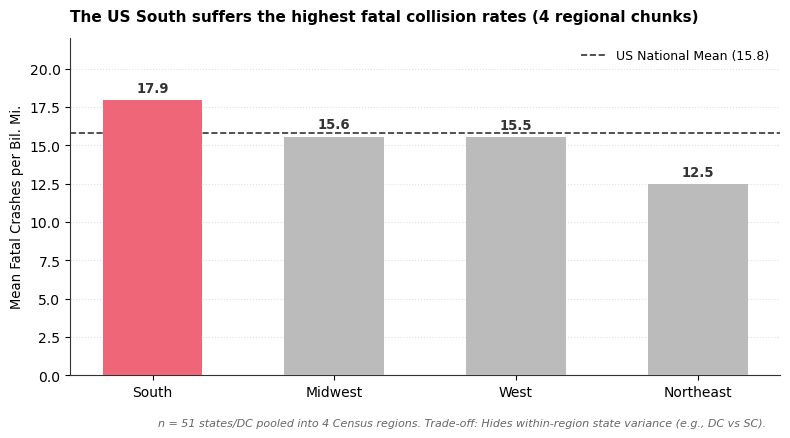

In [4]:
# Define US Census Regions mapping
census_regions = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast', 
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest',
    'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest', 'ND': 'Midwest', 'SD': 'Midwest',
    'DE': 'South', 'DC': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South', 
    'SC': 'South', 'VA': 'South', 'WV': 'South', 'AL': 'South', 'KY': 'South', 'MS': 'South', 
    'TN': 'South', 'AR': 'South', 'LA': 'South', 'OK': 'South', 'TX': 'South',
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West', 'NM': 'West', 
    'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West', 'HI': 'West', 'OR': 'West', 'WA': 'West'
}

df_crashes['region'] = df_crashes['abbrev'].map(census_regions)
region_summary = df_crashes.groupby('region')['total'].agg(['mean', 'count']).sort_values('mean', ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(8, 4.5))

# One pop-out: South in coral red (#ee6677), others in neutral grey (#bbbbbb)
reg_colors = ['#ee6677' if r == 'South' else '#bbbbbb' for r in region_summary['region']]

bars = ax.bar(region_summary['region'], region_summary['mean'], color=reg_colors, width=0.55, zorder=3)
ax.axhline(us_mean, color='#333333', linestyle='--', linewidth=1.2, label=f"US National Mean ({us_mean:.1f})")

# Direct data labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.35, f"{height:.1f}", 
            ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#333333')

ax.set_title("The US South suffers the highest fatal collision rates (4 regional chunks)", 
             loc='left', fontsize=11, fontweight='bold', pad=12)
ax.set_ylabel("Mean Fatal Crashes per Bil. Mi.", fontsize=9.5)
ax.set_ylim(0, 22)
for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.grid(axis='y', linestyle=':', color='#e0e0e0')
ax.legend(frameon=False, loc='upper right', fontsize=9)

# Declaration of chunking cost and sample size
ax.text(0.98, -0.15, "n = 51 states/DC pooled into 4 Census regions. Trade-off: Hides within-region state variance (e.g., DC vs SC).", 
        transform=ax.transAxes, ha='right', fontsize=8, color='#666666', style='italic')

fig.tight_layout()
plt.show()


### Trade-off of Chunking: What Does This Representation Cost?

By reducing 51 states to **4 regional chunks**, we strictly satisfy Cowan's working memory limit (the brain easily compares 4 bars).  
**The Cost:**  
Every aggregation discards variance. In this regional chunking, the extreme within-region differences are concealed:
- In the South, South Carolina has an extreme crash rate of **23.9**, whereas the District of Columbia has the nation's lowest rate of **5.9**. Both are averaged into the South's mean of **17.8**.
- Declaring this trade-off explicitly on the graphic is mandatory for ethical visualization design.


## Step 5: Over-Stripping the Graphic (`BAD EXAMPLE`)

Tufte's data-ink ratio cannot be maximized blindly. To illustrate this failure mode, we strip away all axis titles, all tick marks, all numeric values, and all reference lines.


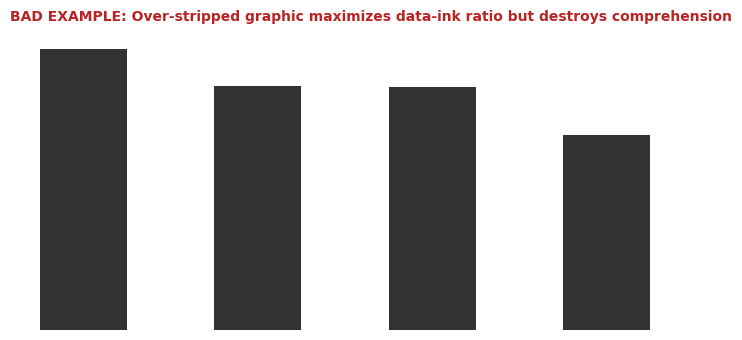

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))

# Over-stripped bars
ax.bar(region_summary['region'], region_summary['mean'], color='#333333', width=0.5)

# Eliminating all coordinates and axes
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("BAD EXAMPLE: Over-stripped graphic maximizes data-ink ratio but destroys comprehension", 
             loc='left', fontsize=10, fontweight='bold', color='#bb2222', pad=10)

fig.tight_layout()
plt.show()


### Why Maximizing Data-Ink Blindly Fails: The Stopping Rule

In the over-stripped chart above, virtually 100% of the ink belongs to data bars (near-perfect data-ink ratio). However, the chart is completely useless:
- The reader cannot determine what the bars represent.
- The reader cannot read the baseline (did the bars start at zero or 10?).
- The reader cannot determine the scale or physical units.

### One-Sentence Stopping Rule for Data-Ink Optimization:
> *"Remove non-data ink until removing one more mark impairs the reader's ability to decode numeric quantities or identify essential coordinate anchors."*


## Step 6: When Adding Ink Lowers Cognitive Load (`tips.csv`)

> *Find one chart where adding ink lowers cognitive load. Explain why 'maximise data-ink' is a heuristic rather than a rule.*

In `tips.csv`, suppose we plot `total_bill` vs `tip`. If we only plot the scatter points, the reader can see the correlation. But if the reader needs to know:
> *"Are customers tipping above or below the standard 15% tipping norm?"*

Without a reference line, the reader must mentally divide $y / x$ for every single data point, incurring enormous cognitive arithmetic load.  
By **adding ink**—specifically a dashed reference line representing the 15% tipping norm and a subtle direct annotation—we eliminate all mental arithmetic.


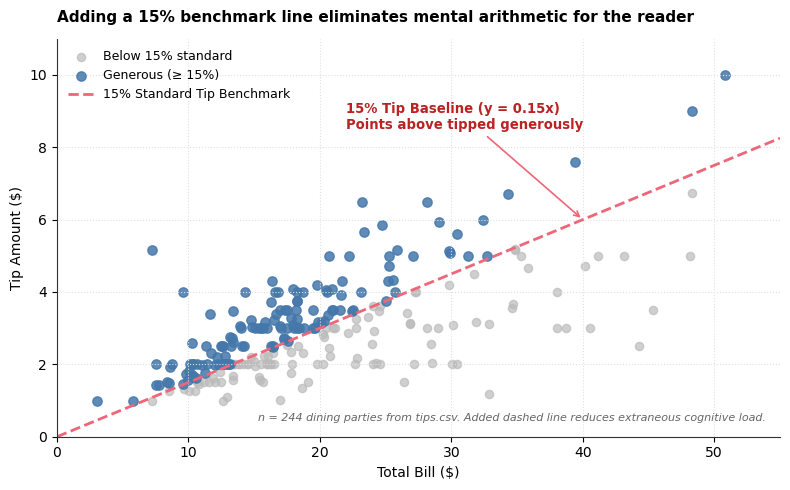

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

# Scatter points: context in grey, generous tips in one pop-out color
above_15 = df_tips['tip'] >= 0.15 * df_tips['total_bill']
ax.scatter(df_tips.loc[~above_15, 'total_bill'], df_tips.loc[~above_15, 'tip'], 
           color='#bbbbbb', s=35, alpha=0.7, label='Below 15% standard')
ax.scatter(df_tips.loc[above_15, 'total_bill'], df_tips.loc[above_15, 'tip'], 
           color='#4477aa', s=45, alpha=0.85, label='Generous (≥ 15%)')

# ADDED INK: 15% reference line (saves mental calculation)
bills = np.linspace(0, 55, 100)
ax.plot(bills, 0.15 * bills, color='#ee6677', linestyle='--', linewidth=2.0, 
        label='15% Standard Tip Benchmark')

# Direct annotation using Gestalt connection/proximity
ax.annotate("15% Tip Baseline (y = 0.15x)\nPoints above tipped generously", 
            xy=(40, 6.0), xytext=(22, 8.5),
            arrowprops=dict(arrowstyle="->", color='#ee6677', lw=1.2),
            fontsize=9.5, fontweight='bold', color='#bb2222')

ax.set_title("Adding a 15% benchmark line eliminates mental arithmetic for the reader", 
             loc='left', fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel("Total Bill ($)", fontsize=10)
ax.set_ylabel("Tip Amount ($)", fontsize=10)
ax.set_xlim(0, 55)
ax.set_ylim(0, 11)
for s in ['top', 'right']: ax.spines[s].set_visible(False)
ax.grid(True, linestyle=':', color='#e0e0e0')
ax.legend(frameon=False, loc='upper left', fontsize=9)

# Declare sample size
ax.text(0.98, 0.04, "n = 244 dining parties from tips.csv. Added dashed line reduces extraneous cognitive load.", 
        transform=ax.transAxes, ha='right', fontsize=8, color='#666666', style='italic')

fig.tight_layout()
plt.show()


### Theoretical Conclusion

The 15% reference line adds ink to the canvas, slightly reducing the mathematical data-ink ratio. However, it **vastly decreases cognitive load** because:
1. It offloads a complex mental calculation ($y / x \ge 0.15$) onto preattentive spatial positioning relative to a reference line.
2. The brain effortlessly registers whether a point sits above or below the line in under 200 ms.
3. Therefore, **maximizing data-ink is an engineering heuristic, not an inviolable law**: any ink that relieves the reader's working memory is high-value, justifiable ink.
